# Exercises for Chapter 15, "Other generalized linear models"

In [1]:
import itertools
import os
import sys

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import special

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [2]:
prng_builder = bg_ros.PRNGBuilder("""
    Chapter 15 here is kind of a crash course in all kinds of stuff you
    can learn about in future classes.  Early on, theres concrete focus
    on fitting some overdispersed distributions with the familiar
    stan_glm library, but later stuff (like Tobit regression, for
    censored data) is merely described and name-checked.
""")

## 15.1, Poisson and negative binomial regression

> The
> [folder `RiskyBehavior`](https://github.com/avehtari/ROS-Examples/tree/master/RiskyBehavior/)
> contains data from a randomized trial targeting couples at high risk of HIV
> infection. The intervention provided counseling sessions regarding practices
> that could reduce their likelihood of contracting HIV. Couples were randomized
> either to a control group, a group in which just the woman participated, or a
> group in which both members of the couple participated. One of the outcomes
> examined after three months was "number of unprotected sex acts."
> 
> (a) Model this outcome as a function of treatment assignment using a Poisson 
>     regression. Does the model fit well? Is there evidence of overdispersion?
> 
> (b) Next extend the model to include pre-treatment measures of the outcome and
>     the additional pre-treatment variables included in the dataset. Does the
>     model fit well? Is there evidence of overdispersion?
> 
> (c) Fit a negative binomial (overdispersed Poisson) model. What do you
>     conclude regarding effectiveness of the intervention?
> 
> (d) These data include responses from both men and women from the
>     participating couples. Does this give you any concern with regard to our
>     modeling assumptions?

In [3]:
rng = prng_builder.new('Exercise 15.1')

In [4]:
risky_df = pandas.read_csv('/home/bgawalt/ros/datasets/risky.csv')
print(bg_ros.dataframe_describe_markdown(risky_df))

|         | couples | women_alone | bupacts | fupacts
--------- | ------- | ----------- | ------- | -------
**count** | 434.00 | 434.00 | 434.00 | 434.00
**mean**  | 0.37 | 0.34 | 25.91 | 16.49
**std**   | 0.48 | 0.47 | 31.92 | 26.83
**min**   | 0.00 | 0.00 | 0.00 | 0.00
**25%**   | 0.00 | 0.00 | 5.00 | 0.00
**50%**   | 0.00 | 0.00 | 15.00 | 5.00
**75%**   | 1.00 | 1.00 | 36.00 | 20.93
**max**   | 1.00 | 1.00 | 300.00 | 200.00



In [5]:
risky_df.head()

,sex,couples,women_alone,bs_hiv,bupacts,fupacts
0,woman,0,1,negative,7,32.0
1,woman,0,0,negative,2,5.0
2,woman,0,0,positive,0,15.0
3,woman,0,0,negative,24,9.0
4,woman,1,0,negative,2,2.0


### 15.1(a)

In [6]:
risky1_model = bambi.Model(
    'fupacts ~ couples + women_alone',
    data=risky_df,
    family='poisson',
)
risky1_fit = risky1_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(risky1_fit, ['couples', 'women_alone']))

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:3004: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, couples, women_alone]


Output()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.       | Mean   | s.e.
----------- | ------ | ------
sigma       | nan | nan
Intercept   | 3.09 | 0.02
couples     | -0.32 | 0.03
women_alone | -0.58 | 0.03



In [7]:
risky1_preds = risky1_model.predict(risky1_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky1_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

In [8]:
act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

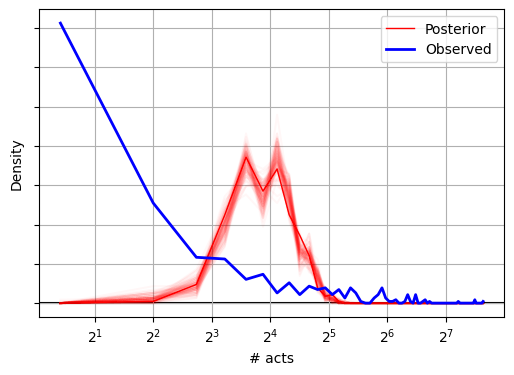

In [9]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

### 15.1(b)

In [10]:
risky2_model = bambi.Model(
    'fupacts ~ couples + women_alone + sex + bs_hiv + bupacts',
    data=risky_df,
    family='poisson',
)
risky2_fit = risky2_model.fit(idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, couples, women_alone, sex, bs_hiv, bupacts]


Output()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/tensor/blas.py:239: RuntimeWarning: invalid value encountered in dot
  out = np.dot(A, x)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


In [11]:
print(bg_ros.bambi_markdown(risky2_fit, ['couples', 'women_alone', 'sex[woman]', 'bs_hiv[positive]', 'bupacts']))

Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | 2.78 | 0.02
couples          | -0.41 | 0.03
women_alone      | -0.67 | 0.03
sex[woman]       | 0.11 | 0.02
bs_hiv[positive] | -0.44 | 0.04
bupacts          | 0.01 | 0.00



In [12]:
risky2_preds = risky2_model.predict(risky2_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky2_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

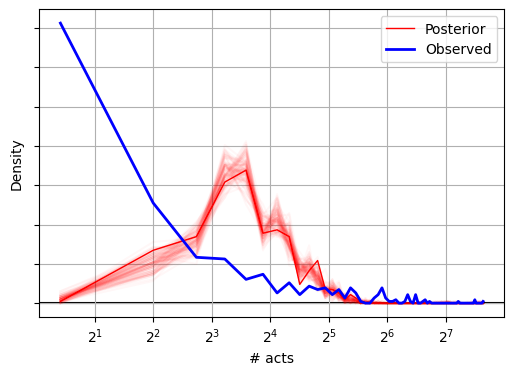

In [13]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

### 15.1(c)

In [14]:
risky3_model = bambi.Model(
    'fupacts ~ couples + women_alone + sex + bs_hiv + bupacts',
    data=risky_df,
    family='negativebinomial',
)
risky3_fit = risky3_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(risky3_fit, ['couples', 'women_alone', 'sex[woman]', 'bs_hiv[positive]', 'bupacts']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, couples, women_alone, sex, bs_hiv, bupacts]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.            | Mean   | s.e.
---------------- | ------ | ------
sigma            | nan | nan
Intercept        | 2.47 | 0.18
couples          | -0.35 | 0.19
women_alone      | -0.73 | 0.20
sex[woman]       | -0.02 | 0.15
bs_hiv[positive] | -0.55 | 0.19
bupacts          | 0.02 | 0.00



In [15]:
risky3_preds = risky3_model.predict(risky3_fit, kind='response', inplace=False)
y_samples = []
for draw in rng.choice(1000, size=100):
    chain = rng.choice(4)
    y_samples.append(
        risky3_preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
    )

act_hist, bin_edges = numpy.histogram(
    risky_df['fupacts'],
    bins=75, density=True)
bin_centers = [0.5 * (l + r) for l, r in itertools.pairwise(bin_edges)]
post_hists = [
    numpy.histogram(ys, bins=bin_edges, density=True)[0]
    for ys in y_samples
]

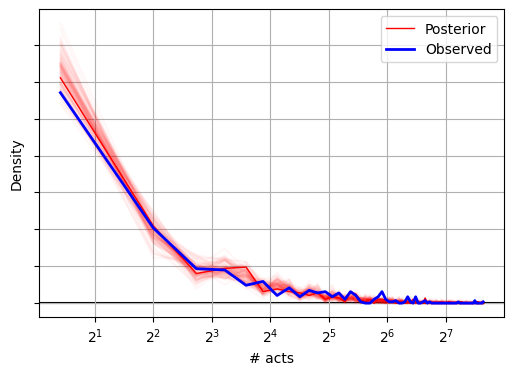

In [16]:
fig = pyplot.figure(figsize=(6, 4))
ax = fig.gca()
for i, ph in enumerate(post_hists):
    if i == 0:
        ax.semilogx(bin_centers, ph, color='r', linewidth=1, label='Posterior', base=2)
    else:
        ax.semilogx(bin_centers, ph, color='r', alpha=0.03, base=2)
ax.semilogx(bin_centers, act_hist, color='b', linewidth=2, label='Observed', base=2)
ax.set_xlabel('# acts')
ax.set_ylabel('Density')
ax.set_yticklabels([])
ax.grid()
ax.axhline(y=0, color='k', zorder=0)
ax.legend()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

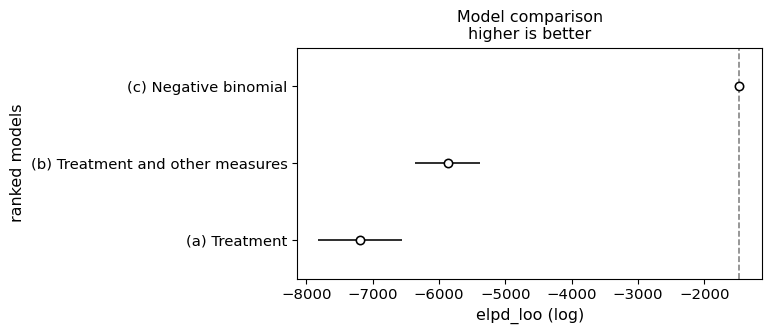

In [17]:
risky_models = {
    '(a) Treatment': risky1_fit,
    '(b) Treatment and other measures': risky2_fit,
    '(c) Negative binomial': risky3_fit,
}
risky_compare = arviz.compare(risky_models)
arviz.plot_compare(risky_compare)

## 15.3, Binomial regression

> Redo the basketball shooting example on page 270, making some changes:
> 
> (a) Instead of having each player shoot 20 times, let the number of shots per
>     player vary, drawn from the uniform distribution between 10 and 30.
> 
> (b) Instead of having the true probability of success be linear, have the true
>     probability be a logistic function, set so that $\text{Pr(success)} = 0.3$
>     for a player who is 5'9" and 0.4 for a 6' tall player.

In [18]:
rng = prng_builder.new('Exercise 15.3')

In [19]:
b = (special.logit(0.4) - special.logit(0.3)) / 3
a = special.logit(0.4) - 72 * b
print(f'a: {a:0.2f}')
print(f'b: {b:0.2f}')

a: -11.01
b: 0.15


In [20]:
num_players = 100
heights = rng.normal(loc=72, scale=3, size=num_players)
ps = special.expit(a + b * heights)
shots = rng.integers(low=10, high=30, endpoint=True, size=num_players)
hits = rng.binomial(shots, ps)
bball_df = pandas.DataFrame(data={'height': heights, 'shots': shots, 'hits': hits})

In [21]:
bball_model = bambi.Model('p(hits, shots) ~ height', bball_df, family='binomial')
bball_fit = bball_model.fit()
print(bg_ros.bambi_markdown(bball_fit, ['height'],))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, height]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -11.02 | 1.10
height    | 0.15 | 0.01



## 15.4, Multinomial logit

> Using the individual-level survey data from the 2000 National Election Study
> (data
> [in folder `NES`](https://github.com/avehtari/ROS-Examples/tree/master/NES/)),
> predict party identification (which is on a five-point scale) using ideology
> and demographics with an ordered multinomial logit model.
> 
> (a) Summarize the parameter estimates numerically and also graphically.
> 
> (b) Explain the results from the fitted model.
> 
> (c) Use a binned residual plot to assess the fit of the model.

In [22]:
nes_parser = bg_ros.DATFileParser('/home/bgawalt/ros/datasets/nes.txt')
nes_parser.add_int_filter('year', lambda y: y == 2000)
nes_df, nes_nas = nes_parser.parse(
    [
        "year", "income", "age", "gender",
        "race", "real_ideo", "martial_status", "partyid7"],
    [],
)
print(bg_ros.dataframe_describe_markdown(nes_df))

|         | year | income | age | gender | race | real_ideo | martial_status | partyid7
--------- | ---- | ------ | --- | ------ | ---- | --------- | -------------- | --------
**count** | 474.00 | 474.00 | 474.00 | 474.00 | 474.00 | 474.00 | 474.00 | 474.00
**mean**  | 2000.00 | 3.03 | 47.61 | 1.53 | 1.53 | 4.31 | 2.01 | 3.82
**std**   | 0.00 | 1.11 | 15.84 | 0.50 | 1.18 | 1.41 | 1.44 | 2.16
**min**   | 2000.00 | 1.00 | 18.00 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00
**25%**   | 2000.00 | 2.00 | 36.00 | 1.00 | 1.00 | 3.00 | 1.00 | 2.00
**50%**   | 2000.00 | 3.00 | 45.00 | 2.00 | 1.00 | 4.00 | 1.00 | 4.00
**75%**   | 2000.00 | 4.00 | 57.75 | 2.00 | 1.00 | 5.00 | 3.00 | 6.00
**max**   | 2000.00 | 5.00 | 91.00 | 2.00 | 5.00 | 7.00 | 7.00 | 7.00



In [23]:
nes_df['party_cat'] = pandas.Categorical(nes_df['partyid7'], ordered=True)
nes_model = bambi.Model(
    'party_cat ~ income + age + gender + real_ideo',
    nes_df,
    family='cumulative',
)
nes_fit = nes_model.fit()

/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/bambi/formula.py:111: UserWarning: The intercept is omitted in ordinal families
  warnings.warn("The intercept is omitted in ordinal families")
Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [threshold, income, age, gender, real_ideo]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


In [24]:
arviz.summary(nes_fit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
threshold[0],-0.388,0.352,-1.075,0.247,0.007,0.005,2682.0,2216.0,1.0
threshold[1],0.420,0.344,-0.249,1.040,0.007,0.005,2803.0,2437.0,1.0
threshold[2],1.173,0.344,0.535,1.835,0.006,0.005,2891.0,2638.0,1.0
threshold[3],1.514,0.348,0.843,2.151,0.007,0.005,2857.0,2775.0,1.0
threshold[4],2.276,0.356,1.618,2.958,0.007,0.005,2926.0,2827.0,1.0
threshold[5],3.315,0.369,2.657,4.039,0.007,0.005,2990.0,2846.0,1.0
income,0.092,0.069,-0.041,0.213,0.001,0.001,3934.0,3141.0,1.0
age,-0.020,0.005,-0.028,-0.010,0.000,0.000,2906.0,2736.0,1.0
gender,-0.581,0.148,-0.856,-0.305,0.003,0.002,3338.0,3042.0,1.0
real_ideo,0.652,0.061,0.542,0.771,0.001,0.001,3079.0,2735.0,1.0


In [25]:
print(bg_ros.bambi_markdown(
    nes_fit,
    [f'threshold[{i}]' for i in range(6)] + ['income', 'age', 'gender', 'real_ideo']
))        

Coef.        | Mean   | s.e.
------------ | ------ | ------
sigma        | nan | nan
Intercept    | nan | nan
threshold[0] | -0.39 | 0.35
threshold[1] | 0.42 | 0.34
threshold[2] | 1.17 | 0.34
threshold[3] | 1.51 | 0.35
threshold[4] | 2.28 | 0.36
threshold[5] | 3.31 | 0.37
income       | 0.09 | 0.07
age          | -0.02 | 0.01
gender       | -0.58 | 0.15
real_ideo    | 0.65 | 0.06



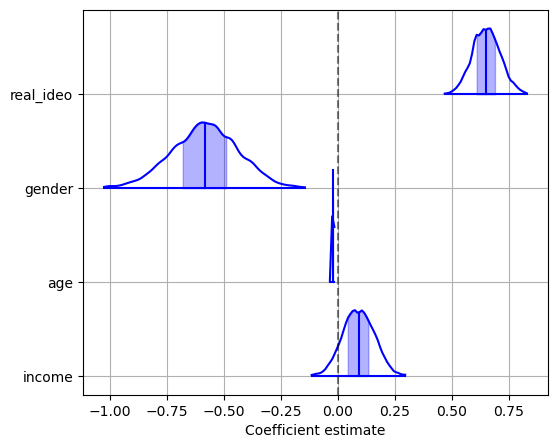

In [26]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
bg_ros.plot_ridge(ax, nes_fit, ['income', 'age', 'gender', 'real_ideo'])

In [27]:
nes_summ = arviz.summary(nes_fit)["mean"]
b_age = nes_summ['age']
b_income = nes_summ['income']
b_gender = nes_summ['gender']
b_ideo = nes_summ['real_ideo']

In [28]:
actual_to_preds = {}
for _, row in nes_df.iterrows():
    pred = (
        row['age'] * b_age +
        row['income'] * b_income +
        row['gender'] * b_gender +
        row['real_ideo'] * b_ideo
    )
    act = int(row['party_cat'])
    if act not in actual_to_preds:
        actual_to_preds[act] = []
    actual_to_preds[act].append(pred)
atp_list = [actual_to_preds[i] for i in sorted(actual_to_preds.keys())]

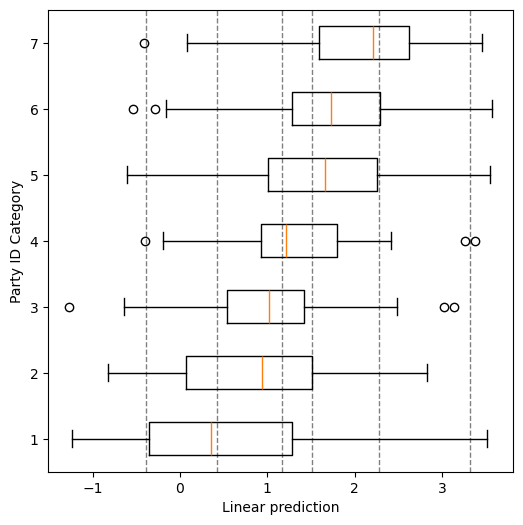

In [29]:
fig = pyplot.figure(figsize=(6, 6))
ax = fig.gca()
ax.boxplot(atp_list, orientation='horizontal')
ax.set_ylabel('Party ID Category')
ax.set_xlabel('Linear prediction')
for k in range(6):
    ax.axvline(nes_summ[f'threshold[{k}]'], color='grey', linewidth=1, linestyle='--', zorder=0)

## 15.5, Comparing logit and probit

> Take one of the data examples from Chapter 13 or 14. Fit these data using both
> logit and probit models. Check that the results are essentially the same after
> scaling by factor of 1.6 (see Figure 15.4).

In [30]:
wells_df = pandas.read_csv('/home/bgawalt/ros/datasets/wells.csv')
wells_df['log_arsenic'] = numpy.log(wells_df['arsenic'])
wells_formula = "switch['1'] ~ dist100 + log_arsenic + dist100:log_arsenic"

In [31]:
wells_logit_model = bambi.Model(
    wells_formula,
    data=wells_df,
    family='bernoulli',
    link='logit',
)
wells_logit_fit = wells_logit_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(wells_logit_fit, ["dist100", "log_arsenic", "dist100:log_arsenic"]))

Modeling the probability that switch==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dist100, log_arsenic, dist100:log_arsenic]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.               | Mean   | s.e.
------------------- | ------ | ------
sigma               | nan | nan
Intercept           | 0.49 | 0.07
dist100             | -0.88 | 0.13
log_arsenic         | 0.98 | 0.11
dist100:log_arsenic | -0.22 | 0.18



In [32]:
wells_probit_model = bambi.Model(
    wells_formula,
    data=wells_df,
    family='bernoulli',
    link='probit',
)
wells_probit_fit = wells_probit_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(wells_probit_fit, ["dist100", "log_arsenic", "dist100:log_arsenic"]))

Modeling the probability that switch==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dist100, log_arsenic, dist100:log_arsenic]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Coef.               | Mean   | s.e.
------------------- | ------ | ------
sigma               | nan | nan
Intercept           | 0.30 | 0.04
dist100             | -0.54 | 0.08
log_arsenic         | 0.59 | 0.07
dist100:log_arsenic | -0.13 | 0.11



In [33]:
for lc, pc in zip([0.49, -0.88, 0.98, -0.23], [0.3, -0.54, 0.59, -0.12]):
    print(lc / pc)

1.6333333333333333
1.6296296296296295
1.6610169491525424
1.9166666666666667


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

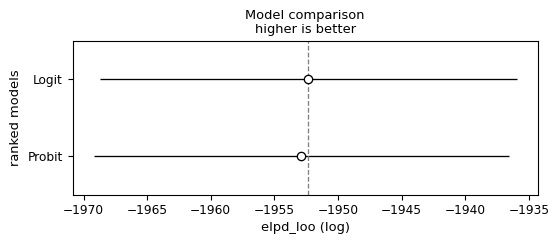

In [34]:
wells_models = {
    'Logit': wells_logit_fit,
    'Probit': wells_probit_fit,
}
wells_compare = arviz.compare(wells_models)
arviz.plot_compare(wells_compare)

## 15.8, Robust linear regression using the $t$ model

> The
> [folder `Congress` has](https://github.com/avehtari/ROS-Examples/tree/master/Congress/)
> the votes for the Democratic and Republican candidates in each U.S.
> congressional district in 1988, along with the parties' vote proportions in
> 1986 and an indicator for whether the incumbent was running for reelection
> in 1988. For your analysis, just use the elections that were contested by both
> parties in both years.
> 
> (a) Fit a linear regression using `stan_glm` with the usual
>     normal-distribution model for the errors predicting 1988 Democratic vote
>     share from the other variables and assess model fit.
> 
> (b) Fit the same sort of model using the brms package with a $t$ distribution,
>     using the `brm` function with the `student` family. Again assess model
>     fit.
> 
> (c) Which model do you prefer?

In [35]:
congress_df = pandas.read_csv('/home/bgawalt/ros/datasets/congress.csv')
congress_df = congress_df[(
    (congress_df['v86'] < 1) &
    (congress_df['v86'] > 0) &
    (congress_df['v88'] < 1) &
    (congress_df['v88'] > 0) 
)]
congress_formula = 'v88 ~ v86 + inc86 + inc88'
congress_df.describe()

,inc86,inc88,inc90,v86,v88,v90,v86_adj,v88_adj,v90_adj
count,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000,316.000000
mean,0.034810,0.085443,0.110759,0.524548,0.518577,0.527908,0.521666,0.515732,0.525313
std,0.947205,0.960643,0.954727,0.191916,0.193119,0.233188,0.187043,0.188276,0.169870
min,-1.000000,-1.000000,-1.000000,0.119715,0.172718,0.000000,0.119715,0.172718,0.224384
25%,-1.000000,-1.000000,-1.000000,0.350483,0.328056,0.367202,0.350483,0.328056,0.367202
50%,0.000000,1.000000,1.000000,0.519730,0.529068,0.545781,0.519730,0.529068,0.545781
75%,1.000000,1.000000,1.000000,0.699948,0.683321,0.660411,0.699948,0.683321,0.660411
max,1.000000,1.000000,1.000000,0.963985,0.960481,1.000000,0.860464,0.883166,0.841058


In [36]:
congress_normal_model = bambi.Model(congress_formula, congress_df, family='gaussian')
congress_normal_fit = congress_normal_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(congress_normal_fit, ['v86', 'inc86', 'inc88']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, v86, inc86, inc88]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 0.07 | 0.00
Intercept | 0.17 | 0.02
v86       | 0.66 | 0.04
inc86     | -0.03 | 0.01
inc88     | 0.10 | 0.01



In [37]:
congress_t_model = bambi.Model(congress_formula, congress_df, family='t')
congress_t_fit = congress_t_model.fit(idata_kwargs={'log_likelihood': True})
print(bg_ros.bambi_markdown(congress_t_fit, ['v86', 'inc86', 'inc88']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, nu, Intercept, v86, inc86, inc88]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 0.06 | 0.00
Intercept | 0.16 | 0.02
v86       | 0.66 | 0.04
inc86     | -0.03 | 0.01
inc88     | 0.10 | 0.01



<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

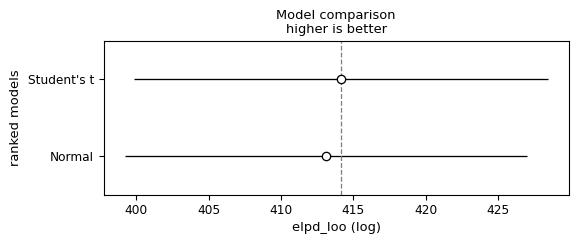

In [38]:
congress_models = {
    "Normal": congress_normal_fit,
    "Student's t": congress_t_fit,
}
congress_compare = arviz.compare(congress_models)
arviz.plot_compare(congress_compare)

In [39]:
print(congress_t_model)

       Formula: v88 ~ v86 + inc86 + inc88
        Family: t
          Link: mu = identity
  Observations: 316
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.5186, sigma: 1.4056)
            v86 ~ Normal(mu: 0.0, sigma: 2.5157)
            inc86 ~ Normal(mu: 0.0, sigma: 0.5097)
            inc88 ~ Normal(mu: 0.0, sigma: 0.5026)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.1928)
            nu ~ Gamma(alpha: 2.0, beta: 0.1)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()


## 15.13 Multinomial choice models

> Pardoe and Simonton (2008) fit a discrete choice model to predict winners of
> the Academy Awards. Their data are in
> [the folder `AcademyAwards`](https://github.com/avehtari/ROS-Examples/tree/master/AcademyAwards).
> 
> (a) Fit your own model to these data.
> 
> (b) Display the fitted model on a plot that also shows the data.
> 
> (c) Make a plot displaying the uncertainty in inferences from the fitted
>     model.

In [40]:
rng = prng_builder.new('Exercise 15.13, the oscars one')

In [41]:
oscars_full_df = pandas.read_csv('/home/bgawalt/ros/datasets/oscars.csv')
oscars_full_df = oscars_full_df[(
    (oscars_full_df['PP'] == 1) &
    (oscars_full_df['Ch'] != 0)
)]
# Trim down the column space:
oscars_df = pandas.DataFrame(data = {
    'best_picture': -1 * oscars_full_df['Ch'] + 2,
    'total_noms': oscars_full_df['Nom'],
    'other_wins': oscars_full_df['Gdr'] + oscars_full_df['Gmc'] + oscars_full_df['PGA']
})
print(bg_ros.dataframe_describe_markdown(oscars_df))

|         | best_picture | total_noms | other_wins
--------- | ------------ | ---------- | ----------
**count** | 453.00 | 453.00 | 453.00
**mean**  | 0.17 | 6.43 | 0.34
**std**   | 0.38 | 2.89 | 0.63
**min**   | 0.00 | 1.00 | 0.00
**25%**   | 0.00 | 4.00 | 0.00
**50%**   | 0.00 | 6.00 | 0.00
**75%**   | 0.00 | 8.00 | 1.00
**max**   | 1.00 | 14.00 | 2.00



In [42]:
oscars_model = bambi.Model("best_picture['1'] ~ total_noms + other_wins", oscars_df, family='bernoulli')
oscars_fit = oscars_model.fit()
print(bg_ros.bambi_markdown(oscars_fit, ['total_noms', 'other_wins']))

Modeling the probability that best_picture==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, total_noms, other_wins]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.      | Mean   | s.e.
---------- | ------ | ------
sigma      | nan | nan
Intercept  | -4.10 | 0.48
total_noms | 0.23 | 0.06
other_wins | 1.56 | 0.22



In [43]:
oscars_summ = arviz.summary(oscars_fit)['mean']
a = oscars_summ['Intercept']
b_nom = oscars_summ['total_noms']
b_win = oscars_summ['other_wins']

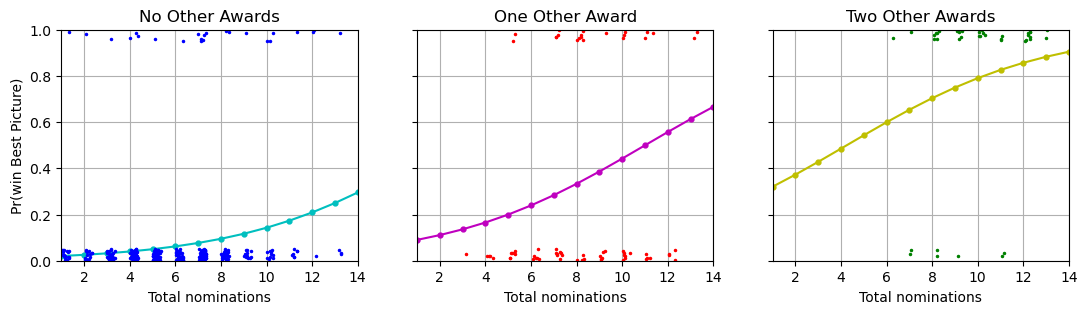

In [44]:
fig, axs = pyplot.subplots(nrows=1, ncols=3, figsize=(13, 3), sharey=True)
xs = numpy.arange(1, 15)

oscars_nowins_df = oscars_df[oscars_df['other_wins'] == 0]
n_nowins = oscars_nowins_df.shape[0]
axs[0].plot(xs, special.expit(a + b_nom * xs), marker='.', markersize=7, color='c')
axs[0].plot(
    oscars_nowins_df['total_noms'] + rng.uniform(high=0.35, size=n_nowins),
    0.95 * oscars_nowins_df['best_picture'] + rng.uniform(high=0.05, size=n_nowins),
    marker='.',
    linewidth=0,
    markersize=3,
    color='b',
)
axs[0].set_title('No Other Awards')
axs[0].set_ylabel('Pr(win Best Picture)')

oscars_wins_df = oscars_df[oscars_df['other_wins'] == 1]
n_wins = oscars_wins_df.shape[0]
axs[1].plot(xs, special.expit(a + b_nom * xs + b_win), marker='.', markersize=7, color='m')
axs[1].plot(
    oscars_wins_df['total_noms'] + rng.uniform(high=0.35, size=n_wins),
    0.95 * oscars_wins_df['best_picture'] + rng.uniform(high=0.05, size=n_wins),
    marker='.',
    linewidth=0,
    markersize=3,
    color='r',
)
axs[1].set_title('One Other Award')

oscars_wins_df = oscars_df[oscars_df['other_wins'] == 2]
n_wins = oscars_wins_df.shape[0]
axs[2].plot(xs, special.expit(a + b_nom * xs + 2 * b_win), marker='.', markersize=7, color='y')
axs[2].plot(
    oscars_wins_df['total_noms'] + rng.uniform(high=0.35, size=n_wins),
    0.95 * oscars_wins_df['best_picture'] + rng.uniform(high=0.05, size=n_wins),
    marker='.',
    linewidth=0,
    markersize=3,
    color='g',
)
axs[2].set_title('Two Other Awards')

for ax in axs:
    ax.grid()
    ax.set_axisbelow(True)
    ax.set_xlim(1, 14)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Total nominations')

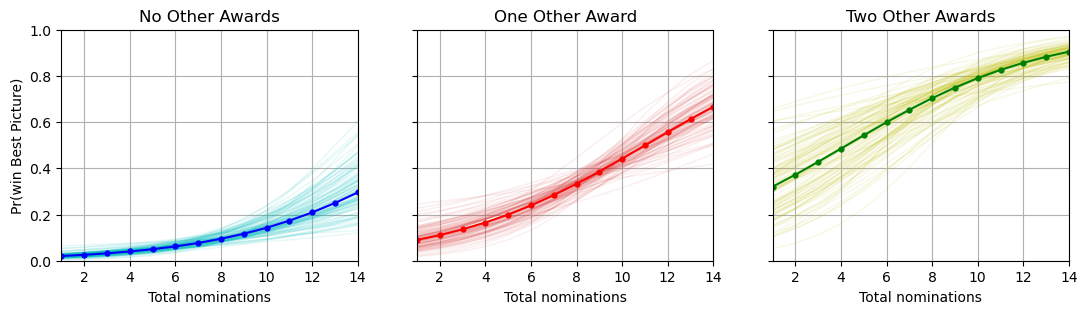

In [45]:
posterior = bg_ros.bambi_flatten(oscars_fit, ['Intercept', 'total_noms', 'other_wins'])
for v in posterior.values():
    assert len(v) == 4000
triples = [
    (posterior['Intercept'][i], posterior['total_noms'][i], posterior['other_wins'][i])
    for i in rng.integers(0, 4000, 100)
]

fig, axs = pyplot.subplots(nrows=1, ncols=3, figsize=(13, 3), sharey=True)
xs = numpy.arange(1, 15)

oscars_nowins_df = oscars_df[oscars_df['other_wins'] == 0]
n_nowins = oscars_nowins_df.shape[0]
for ai, bni, bwi in triples:
    axs[0].plot(xs, special.expit(ai + bni * xs), linewidth=1, alpha=0.1, markersize=0, color='c')
axs[0].plot(xs, special.expit(a + b_nom * xs), marker='.', markersize=7, color='b')
axs[0].set_title('No Other Awards')
axs[0].set_ylabel('Pr(win Best Picture)')

oscars_wins_df = oscars_df[oscars_df['other_wins'] == 1]
n_wins = oscars_wins_df.shape[0]
for ai, bni, bwi in triples:
    axs[1].plot(xs, special.expit(ai + bni * xs + bwi), linewidth=1, alpha=0.08, markersize=0, color='tab:red')
axs[1].plot(xs, special.expit(a + b_nom * xs + b_win), marker='.', markersize=7, color='r')
axs[1].set_title('One Other Award')

oscars_wins_df = oscars_df[oscars_df['other_wins'] == 2]
n_wins = oscars_wins_df.shape[0]
for ai, bni, bwi in triples:
    axs[2].plot(xs, special.expit(ai + bni * xs + 2 * bwi), linewidth=1, alpha=0.1, markersize=0, color='y')
axs[2].plot(xs, special.expit(a + b_nom * xs + 2 * b_win), marker='.', markersize=7, color='g')
axs[2].set_title('Two Other Awards')

for ax in axs:
    ax.grid()
    ax.set_axisbelow(True)
    ax.set_xlim(1, 14)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Total nominations')

## 15.14, Model checking for count data

> The folder `RiskyBehavior` contains data from a study of behavior of couples
> at risk for HIV; see Exercise 15.1.
> 
> (a) Fit a Poisson regression predicting number of unprotected sex acts from
>     baseline HIV status. Perform predictive simulation to generate 1000
>     datasets and record the percentage of observations that are equal to 0 and
>     the percentage that are greater than 10 (the third quartile in the
>     observed data) for each. Compare these to the observed value in the
>     original data.
> 
> (b) Repeat (a) using a negative binomial (overdispersed Poisson) regression.
> 
> (c) Repeat (b), also including ethnicity and baseline number of unprotected
>     sex acts as inputs.

In [46]:
rng = prng_builder.new('Exercise 15.14')

In [47]:
risky_df['hiv_pos'] = [1 if hi == 'positive' else 0 for hi in risky_df['bs_hiv']]
risky_df['is_woman'] = [1 if si == 'woman' else 0 for si in risky_df['sex']]
risky_df.describe()

,couples,women_alone,bupacts,fupacts,hiv_pos,is_woman
count,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000
mean,0.373272,0.336406,25.910138,16.489579,0.223502,0.500000
std,0.484232,0.473025,31.917963,26.825769,0.417073,0.500577
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,15.000000,5.000000,0.000000,0.500000
75%,1.000000,1.000000,36.000000,20.925600,0.000000,1.000000
max,1.000000,1.000000,300.000000,200.000000,1.000000,1.000000


In [48]:
n = risky_df.shape[0]
orig_zero_pct = float(sum(1 if yi == 0 else 0 for yi in risky_df['fupacts'])) / n
orig_ten_pct = float(sum(1 if yi > 10 else 0 for yi in risky_df['fupacts'])) / n
print(f'Zero pct (orig): {100 * orig_zero_pct: 0.1f}' + '%')
print(f'Zero pct (orig): {100 * orig_ten_pct: 0.1f}' + '%')

Zero pct (orig):  29.3%
Zero pct (orig):  36.4%


In [49]:
def counts(model: bambi.Model):
    fit = model.fit()
    preds = model.predict(fit, kind='response', inplace=False)
    zero_pcts = []
    ten_pcts = []
    for chain in range(4):
        for draw in rng.choice(1000, size=250):
            ys = preds.posterior_predictive['fupacts'].sel(chain=chain, draw=draw).to_dataframe()['fupacts']
            zero_pcts.append(float(sum(1 if yi == 0 else 0 for yi in ys)) / len(ys))
            ten_pcts.append(float(sum(1 if yi > 10 else 0 for yi in ys)) / len(ys))
    return zero_pcts, ten_pcts

In [50]:
def plot_counts(ax: pyplot.Axes, zeros, tens, xlim):
    bins = numpy.linspace(0.01, 0.99, 99)
    ax.hist(zeros, bins=150, range=(0, 1), color='b', alpha=0.5, label='Pred = 0', density=True)
    ax.hist(tens, bins=150, range=(0, 1), color='r', alpha=0.5, label='Pred > 10', density=True)
    ax.axvline(orig_zero_pct, color='b', linestyle='--')
    ax.axvline(orig_ten_pct, color='r', linestyle='--')
    ax.set_yticklabels([])
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_xlabel('Share of predictions')
    ax.legend()
    ax.grid()

In [51]:
risky_poi = bambi.Model(
    'fupacts ~ hiv_pos',
    data=risky_df,
    family='poisson',
)

poi_zeros, poi_tens = counts(risky_poi)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, hiv_pos]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


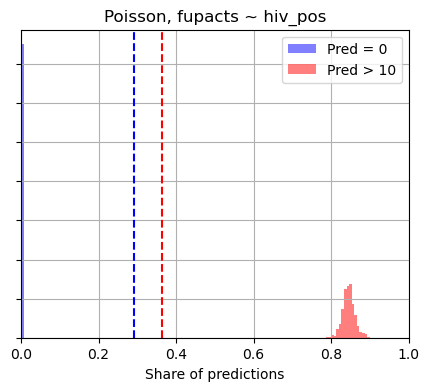

In [52]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.set_title('Poisson, fupacts ~ hiv_pos')
plot_counts(ax, poi_zeros, poi_tens, [0, 1])

In [53]:
risky_nb1 = bambi.Model(
    'fupacts ~ hiv_pos',
    data=risky_df,
    family='negativebinomial',
)

nb1_zeros, nb1_tens = counts(risky_nb1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, hiv_pos]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


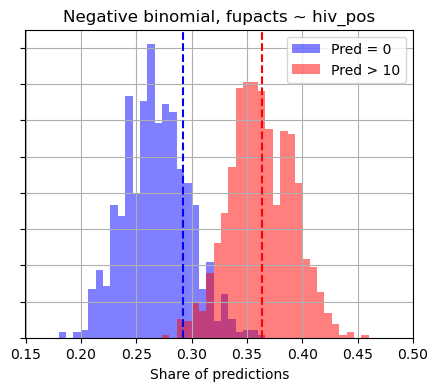

In [55]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.set_title('Negative binomial, fupacts ~ hiv_pos')
plot_counts(ax, nb1_zeros, nb1_tens, [0.15, 0.5])

In [56]:
risky_nb2 = bambi.Model(
    'fupacts ~ hiv_pos + is_woman + bupacts',
    data=risky_df,
    family='negativebinomial',
)

nb2_zeros, nb2_tens = counts(risky_nb2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, hiv_pos, is_woman, bupacts]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


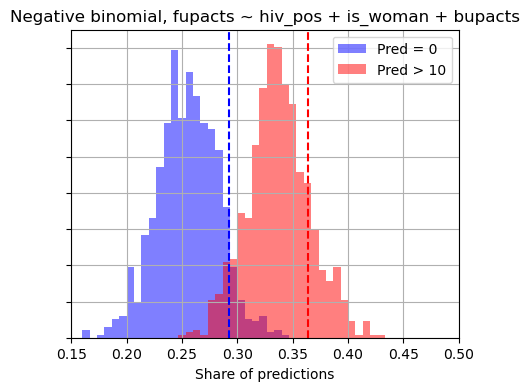

In [57]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.set_title('Negative binomial, fupacts ~ hiv_pos + is_woman + bupacts')
plot_counts(ax, nb2_zeros, nb2_tens, [0.15, 0.5])